[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ddmms/camml-tutorials/blob/main/notebooks/05-generative/chemeleon-crystals.ipynb)

Source repo for Colab bootstrap and helper downloads: <https://gitlab.com/cam-ml/tutorials/-/tree/main/notebooks/05-generative>


# Chemeleon-DNG in Practice: DNG and CSP for crystal generation

<img src="https://raw.githubusercontent.com/hspark1212/chemeleon/main/assets/logo_static.jpg" alt="Chemeleon logo figure from the official repository" width="52%"> <img src="https://raw.githubusercontent.com/hspark1212/chemeleon/main/assets/trajectory.gif" alt="Chemeleon trajectory gif from the official repository" width="18%">

*Source:* official Chemeleon repository assets `assets/logo_static.jpg` and `assets/trajectory.gif`: <https://github.com/hspark1212/chemeleon>

The main Chemeleon repository is text-guided, while this notebook focuses on the `chemeleon-dng` branch for DNG and CSP. These upstream visuals still help because they show the broader project identity and a real crystal-generation trajectory from the same model family.

This notebook follows the same scientific pattern as the MatterGen notebook, but the user-facing interface is different. Chemeleon-DNG exposes two explicit tasks: open-ended **DNG** and formula-conditioned **CSP**.

## Where this fits in the course

- `diffusion-fundamentals.ipynb`: the forward / reverse diffusion story is unchanged.
- `crystal-diffusion-from-scratch.ipynb`: the crystal representation and screening logic should already feel familiar.
- `mattergen-crystals.ipynb`: use that notebook as the reference point for scalar-property steering, then use this notebook to contrast task-oriented control.

## Aims

- install and run Chemeleon-DNG in a notebook-friendly way,
- generate crystals in open-ended DNG mode,
- steer DNG with different atom-count schedules,
- generate formula-conditioned candidates with CSP,
- compare conditioning and screening in a second modern crystal-generation workflow.

## Learning outcomes

By the end you should be able to:

1. explain the difference between DNG and CSP,
2. identify which Chemeleon controls act *during* sampling and which diagnostics act *after* sampling,
3. compare formula-conditioned generation to MatterGen's scalar-target workflow,
4. decide when a task-oriented toolkit is the better fit for a computational-chemistry question.

## How to use this notebook

1. Run the DNG quickstart first so the environment and checkpoints are in place.
2. Treat the DNG steering study as a lesson in **sampling control**, not in explicit conditioning.
3. Use the optional SMACT section if you want a more principled way to choose CSP formulas.
4. Treat the CSP study as the main conditional-generation demo because the requested formula is directly verifiable.
5. Use the optional relaxation and phase-diagram cells as the closest continuation of the upstream `tutorial.ipynb` workflow.
6. Keep one running note with three labels: `task`, `control knob`, `screening statistic`.


## Primary sources and upstream code

This notebook is organized around the official Chemeleon resources:

- Chemeleon repository and paper: https://github.com/hspark1212/chemeleon and https://www.nature.com/articles/s41467-025-59636-y
- Chemeleon-DNG repository: https://github.com/hspark1212/chemeleon-dng
- Chemeleon-DNG commit pinned in this notebook: `0d8da3a82a0c2211245a1b1394b599ca0545883c`
- Local upstream discovery tutorial used for the optional workflow extension below: `chemeleon_dng_repo/tutorial.ipynb`

The goal is not to retrain the model family. The goal is to understand how to run, inspect, and compare the two user-facing tasks in practice.


## Table of Contents

1. [Setup](#1-setup)
2. [How it works](#2-how-it-works)
3. [DNG quickstart](#3-dng-quickstart-generate-crystals-from-scratch)
4. [DNG steering and output analysis](#4-dng-steering-and-output-analysis)
5. [Optional: SMACT formula screening before CSP](#optional-smact-formula-screening-before-csp)
6. [CSP quickstart: formula-conditioned generation](#5-csp-quickstart-formula-conditioned-generation)
7. [CSP conditioning shifts, galleries, and screening](#6-csp-conditioning-shifts-galleries-and-screening)
8. [Optional: relaxation and stability triage](#optional-relaxation-and-stability-triage)
9. [When to choose Chemeleon-DNG](#7-when-to-choose-chemeleon-dng)
10. [Exercises](#8-exercises)
11. [Troubleshooting](#9-troubleshooting)
12. [Next steps](#10-next-steps)


**Task for you**
<div class="alert alert-block alert-info">

- Before you run anything, write one sentence that distinguishes **open-ended generation**, **sampling control**, and **explicit conditioning**.
- Keep comparing to `mattergen-crystals.ipynb`: what is the first question a user asks in each toolkit?
- Decide ahead of time which Chemeleon task seems closer to the inverse-design problems you care about.

</div>


## 1) Setup

This section installs a clean `chemeleon-dng` environment and leaves the checkpoint download to the first real sampling call.

A small but important implementation detail: the notebook creates the Python environment in the system temporary directory rather than inside the repo. That avoids incomplete `torch` and `numpy` installs on mounted drives such as OneDrive, WSL bind mounts, and some Colab-backed filesystems.

What this setup cell does:

- validates or reclones the `chemeleon-dng` repository,
- checks out the pinned commit `0d8da3a82a0c`,
- creates a clean Python 3.11 environment in a temporary directory,
- installs `chemeleon-dng` into that environment,
- verifies that `chemeleon_dng`, `numpy`, and `torch` all import cleanly,
- defines the helper functions used by the DNG and CSP demos below.

The first DNG or CSP sample will automatically download about $523\,\mathrm{{MB}}$ of pretrained checkpoints into `chemeleon_dng_repo/ckpts/`. Later runs reuse those files.


In [1]:
from pathlib import Path
import html
import os
import subprocess
import sys

DAY5_SOURCE_REPO_URL = "https://gitlab.com/cam-ml/tutorials.git"
DAY5_SOURCE_REPO_BRANCH = "main"
DAY5_COLAB_CLONE_CANDIDATES = [
    Path("/content/tutorials"),
    Path("/content/cam_ml_tutorials"),
    Path("/content/camml-tutorials"),
]


def _running_in_colab():
    try:
        import google.colab  # type: ignore
        return True
    except Exception:
        return False


def _unique_paths(paths):
    unique = []
    seen = set()
    for path in paths:
        path = Path(path)
        key = str(path)
        if key not in seen:
            seen.add(key)
            unique.append(path)
    return unique


def _iter_day5_search_roots():
    cwd = Path.cwd().resolve()
    roots = [cwd, *cwd.parents]
    for clone_dir in DAY5_COLAB_CLONE_CANDIDATES:
        roots.extend([clone_dir, clone_dir / "notebooks" / "05-generative"])
    return _unique_paths(roots)


def _register_day5_notebook_root(notebook_root: Path):
    notebook_root = notebook_root.resolve()
    if str(notebook_root) not in sys.path:
        sys.path.insert(0, str(notebook_root))
    try:
        os.chdir(notebook_root)
    except OSError:
        pass
    return notebook_root


def ensure_day5_helpers_on_path():
    for candidate in _iter_day5_search_roots():
        for notebook_root in (candidate, candidate / "notebooks" / "05-generative"):
            helper_dir = notebook_root / "gen_helpers"
            if helper_dir.exists():
                return _register_day5_notebook_root(notebook_root)

    if _running_in_colab():
        for clone_dir in DAY5_COLAB_CLONE_CANDIDATES:
            notebook_root = clone_dir / "notebooks" / "05-generative"
            if notebook_root.exists():
                return _register_day5_notebook_root(notebook_root)

        for clone_dir in DAY5_COLAB_CLONE_CANDIDATES:
            if clone_dir.exists():
                continue
            clone_dir.parent.mkdir(parents=True, exist_ok=True)
            print(
                "Cloning the Day 5 tutorial repo from "
                f"{DAY5_SOURCE_REPO_URL} into {clone_dir} so notebook helper modules are available..."
            )
            subprocess.run(
                [
                    "git",
                    "clone",
                    "--depth",
                    "1",
                    "--branch",
                    DAY5_SOURCE_REPO_BRANCH,
                    DAY5_SOURCE_REPO_URL,
                    str(clone_dir),
                ],
                check=True,
            )
            notebook_root = clone_dir / "notebooks" / "05-generative"
            if notebook_root.exists():
                return _register_day5_notebook_root(notebook_root)

        raise FileNotFoundError(
            "Could not find or clone notebooks/05-generative inside /content for this Colab session."
        )

    raise FileNotFoundError(
        "Could not locate notebooks/05-generative/gen_helpers. If you are in Colab, rerun this cell so the repo can be cloned automatically."
    )

GEN_HELPERS_ROOT = ensure_day5_helpers_on_path()

try:
    import ipywidgets as widgets
except Exception:
    widgets = None

try:
    import google.colab  # type: ignore
    IN_COLAB = True
except Exception:
    IN_COLAB = False

from IPython.display import display

from gen_helpers.discovery_workflow import (
    build_generated_pd_entries,
    build_relaxation_rows,
    fetch_mp_entries_for_chemsys,
    get_valid_compositions,
    plot_phase_diagram_with_generated,
    relax_atoms_with_mace,
    show_before_after_relaxation,
    summarize_generated_stability,
)
from gen_helpers.chemeleon_helpers import (
    analyze_csp_samples,
    analyze_dng_runs,
    render_rank_table,
    sample_chemeleon_dng as _sample_chemeleon_dng,
    setup_chemeleon_dng_environment,
    show_atoms_gallery,
)

chemeleon_env = setup_chemeleon_dng_environment()
notebook_root = chemeleon_env["notebook_root"]
CHEMELEON_DNG_REPO = chemeleon_env["repo_dir"]
CHEMELEON_DNG_OUT = chemeleon_env["output_dir"]
CHEMELEON_DNG_VENV = chemeleon_env["venv_dir"]
CHEMELEON_DNG_PYTHON = chemeleon_env["python_path"]
CHEMELEON_DNG_CLI = chemeleon_env["cli_path"]
CHEMELEON_DNG_DEVICE = chemeleon_env["device"]
CHEMELEON_DNG_DEMO_TIMESTEPS = chemeleon_env["demo_timesteps"]
CHEMELEON_DNG_COMMIT = chemeleon_env["pinned_commit"]
CHEMELEON_DNG_CHECKPOINT_DATASET = 'alex_mp_20'
CHEMELEON_DNG_PRIOR_NAME = 'mp-20'
CHEMELEON_DNG_ALEX_MP20_MODEL_PATH = 'ckpts/chemeleon_dng_alex_mp_20_v0.0.2.ckpt'
CHEMELEON_CSP_ALEX_MP20_MODEL_PATH = 'ckpts/chemeleon_csp_alex_mp_20_v0.0.2.ckpt'


def sample_chemeleon_dng(**kwargs):
    return _sample_chemeleon_dng(chemeleon_env, **kwargs)


def format_widget_pre(text: str) -> str:
    return f"<pre style='white-space:pre-wrap; margin:0'>{html.escape(text)}</pre>"


def bind_widget_state(controls, apply_fn):
    state_holder = {"has_rendered": False, "last": None}

    def refresh(change=None):
        state = {name: control.value for name, control in controls.items()}
        state_key = tuple((name, repr(value)) for name, value in state.items())
        if state_holder["has_rendered"] and state_holder["last"] == state_key:
            return
        state_holder["has_rendered"] = True
        state_holder["last"] = state_key
        apply_fn(**state)

    refresh()
    for control in controls.values():
        control.observe(refresh, names='value')
    return refresh


Python: 3.12.13 (main, Apr 10 2026, 10:56:24) [GCC 11.4.0]
Working dir: /home/uccabaa/repositories/tutorials/notebooks/05-generative
Notebook root: /home/uccabaa/repositories/tutorials/notebooks/05-generative
Using existing Chemeleon-DNG clone: /home/uccabaa/repositories/tutorials/notebooks/05-generative/chemeleon_dng_repo


HEAD is now at 0d8da3a chore: Add CLAUDE.md to .gitignore


/home/uccabaa/repositories/tutorials/notebooks/05-generative/chemeleon_dng_repo/chemeleon_dng/__init__.py
2.4.4
2.11.0+cu130
Chemeleon-DNG repo: /home/uccabaa/repositories/tutorials/notebooks/05-generative/chemeleon_dng_repo
Chemeleon-DNG commit: 0d8da3a
Pinned Chemeleon-DNG commit: 0d8da3a82a0c2211245a1b1394b599ca0545883c
Chemeleon-DNG venv: /tmp/chemeleon-dng-venv
Chemeleon-DNG Python: /tmp/chemeleon-dng-venv/bin/python
Chemeleon-DNG CLI: /tmp/chemeleon-dng-venv/bin/chemeleon-dng
Default notebook device: cuda
Notebook demo timesteps: 32


## 2) How it works

Chemeleon-DNG exposes one diffusion backbone through two user-facing tasks: DNG and CSP.

### Shared backbone
At the model level, both tasks follow the same core recipe:

1. represent a crystal by atom identities, fractional coordinates, and lattice information,
2. corrupt that representation step by step,
3. train a denoiser to reverse the corruption,
4. sample by iteratively denoising from a simple starting distribution.

### Where the control enters

- **DNG:** no target formula is provided. The main control shown here is the atom-count distribution, which biases the search toward smaller or larger cells.
- **CSP:** the target formula is fixed before sampling. The model then searches for plausible structures consistent with that chemistry.

### Comparison with MatterGen

- MatterGen keeps the same raw-crystal viewpoint but adds scalar-property steering.
- Chemeleon-DNG keeps the diffusion backbone but reorganizes the workflow around task choice.
- That means the first user question changes:
  - **MatterGen:** what scalar target do I want?
  - **Chemeleon-DNG:** do I want open-ended discovery or fixed-formula search?

> **Quick check:** what is shared between DNG and CSP, and what changes?
>
><details><summary>Answer</summary>
>
>They share the same broad diffusion backbone for denoising crystal representations. What changes is the conditioning interface: DNG is open-ended and uses schedule steering, while CSP conditions on a target formula.
>
></details>


### Dataset note

Chemeleon-DNG provides checkpoints trained on both `mp-20` and `alex_mp_20`. In this notebook we explicitly use the `alex_mp_20` DNG and CSP checkpoints. For the open-ended DNG runs, however, the current repo only ships one built-in atom-count prior in `NUM_ATOM_DISTRIBUTIONS`, keyed as `mp-20`. So the DNG demos below use the `alex_mp_20` checkpoint together with the repo's available `mp-20` atom-count prior. The repo also notes that these checkpoints use a reduced `256`-step diffusion process for faster inference. So when you judge the generated samples, it is worth remembering that the prior still comes from a small-cell inorganic crystal dataset, not from the full text-guided `mp-40` setup described in the main Chemeleon repository.


## 3) DNG quickstart: generate crystals from scratch

We start Chemeleon-DNG with the purest task: de novo generation.

This first call still plays two roles:

- it checks that the repo-local Chemeleon-DNG environment is working,
- and it gives us a baseline DNG batch before we start steering the atom-count schedule in the next section.

### What to notice

- DNG does not need a target formula.
- The first call may still download checkpoints if `ckpts/` is empty.
- The notebook uses a reduced demo-length reverse process so this quickstart stays practical on CPU.
- After the quickstart batch, we can ask a more interesting question: how much can we move the output distribution by changing the atom-count schedule?


Reusing 8 existing CIF files from /home/uccabaa/repositories/tutorials/notebooks/05-generative/results_chemeleon_dng/dng_quickstart
Generated: 8 structures
  sample 0: H6O2 | 8 atoms | volume=19.4 A^3
  sample 1: H18Be | 19 atoms | volume=19.5 A^3
  sample 2: H16O4 | 20 atoms | volume=21.8 A^3
  sample 3: H4 | 4 atoms | volume=10.1 A^3
  sample 4: H7Be2Ni | 10 atoms | volume=2.4 A^3


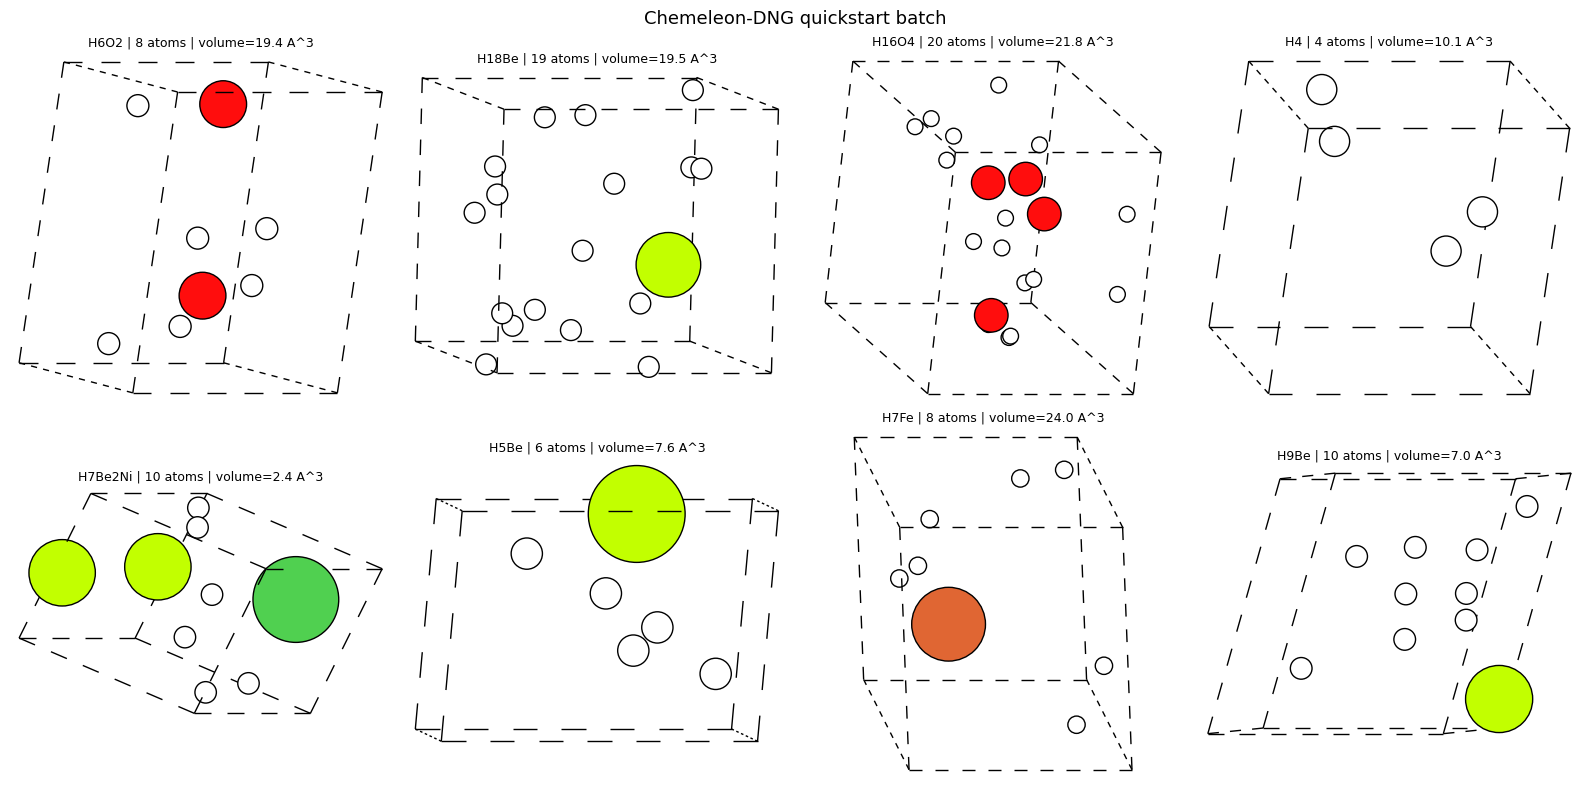

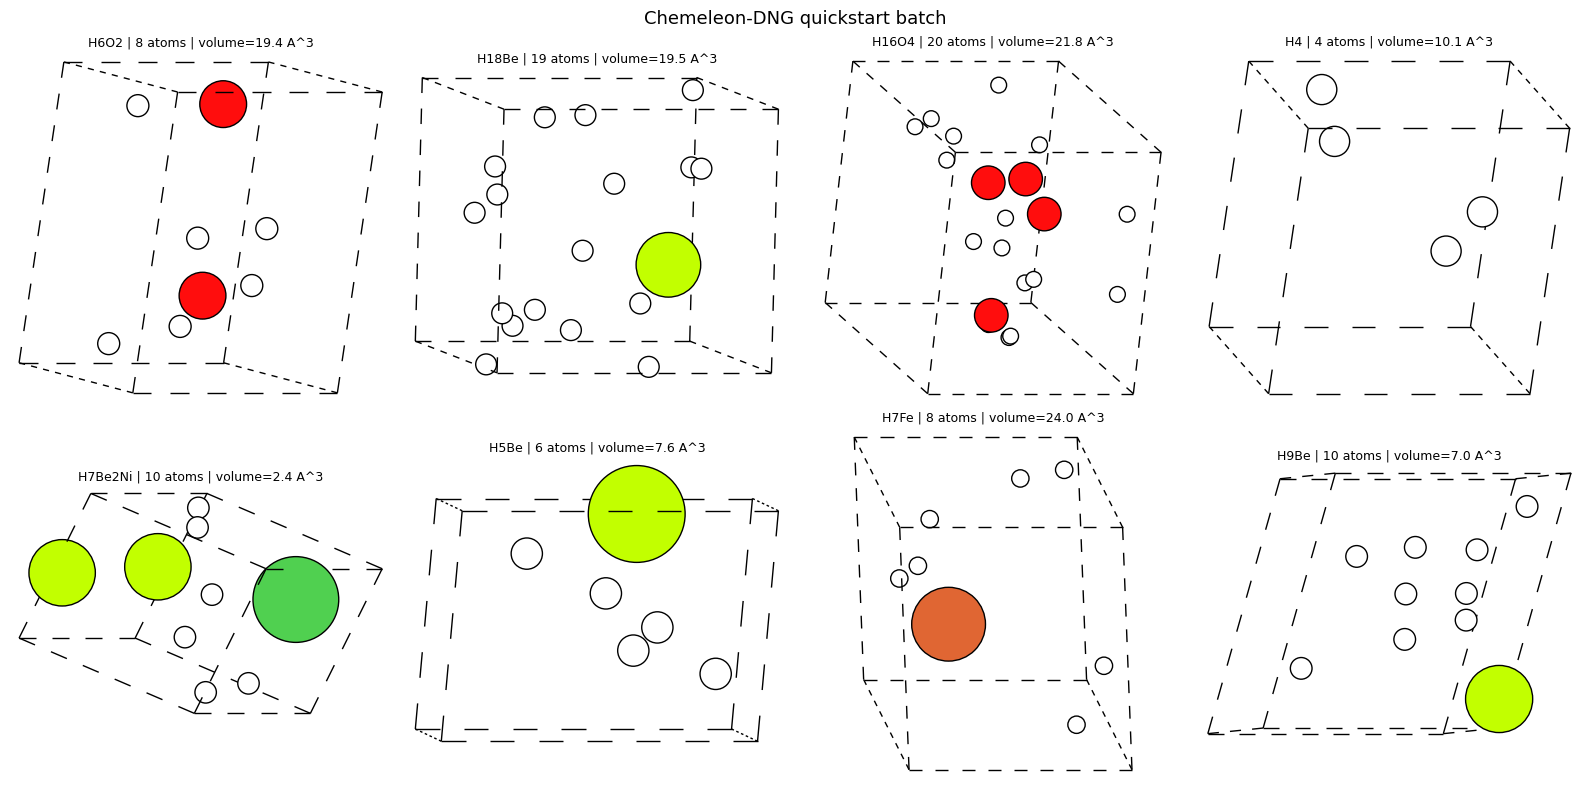

In [2]:
from ase.io import read

CHEMELEON_DNG_QUICKSTART_NUM_SAMPLES = int(globals().get("CHEMELEON_DNG_QUICKSTART_NUM_SAMPLES", 8))  # @param {type:"integer"}
CHEMELEON_DNG_QUICKSTART_BATCH_SIZE = int(globals().get("CHEMELEON_DNG_QUICKSTART_BATCH_SIZE", 8))  # @param {type:"integer"}
CHEMELEON_DNG_QUICKSTART_REUSE_EXISTING = globals().get("CHEMELEON_DNG_QUICKSTART_REUSE_EXISTING", True)  # @param {type:"boolean"}


def _chemeleon_quickstart_summary() -> str:
    lines = [
        "Chemeleon-DNG quickstart settings:",
        f"  num_samples: {CHEMELEON_DNG_QUICKSTART_NUM_SAMPLES}",
        f"  batch_size: {CHEMELEON_DNG_QUICKSTART_BATCH_SIZE}",
        f"  atom-count prior: {CHEMELEON_DNG_PRIOR_NAME}",
        f"  checkpoint dataset: {CHEMELEON_DNG_CHECKPOINT_DATASET}",
        f"  checkpoint: {CHEMELEON_DNG_ALEX_MP20_MODEL_PATH}",
        f"  reuse_existing: {CHEMELEON_DNG_QUICKSTART_REUSE_EXISTING}",
    ]
    if not IN_COLAB and widgets is not None:
        lines.append("Adjust the widgets, then rerun this cell to resample the DNG quickstart batch.")
    return "\n".join(lines)


def _apply_chemeleon_quickstart_controls(num_samples, batch_size, reuse_existing, announce: bool = True):
    global CHEMELEON_DNG_QUICKSTART_NUM_SAMPLES, CHEMELEON_DNG_QUICKSTART_BATCH_SIZE, CHEMELEON_DNG_QUICKSTART_REUSE_EXISTING
    CHEMELEON_DNG_QUICKSTART_NUM_SAMPLES = int(num_samples)
    CHEMELEON_DNG_QUICKSTART_BATCH_SIZE = int(batch_size)
    CHEMELEON_DNG_QUICKSTART_REUSE_EXISTING = bool(reuse_existing)
    summary = _chemeleon_quickstart_summary()
    if announce:
        print(summary)
    return summary


if IN_COLAB or widgets is None:
    print(
        _apply_chemeleon_quickstart_controls(
            CHEMELEON_DNG_QUICKSTART_NUM_SAMPLES,
            CHEMELEON_DNG_QUICKSTART_BATCH_SIZE,
            CHEMELEON_DNG_QUICKSTART_REUSE_EXISTING,
            announce=False,
        )
    )
    if not IN_COLAB and widgets is None:
        print("Install `ipywidgets` to get Jupyter controls for this cell.")
else:
    quickstart_samples_widget = widgets.BoundedIntText(
        value=CHEMELEON_DNG_QUICKSTART_NUM_SAMPLES,
        min=1,
        max=16,
        description="Samples:",
        style={"description_width": "70px"},
        layout=widgets.Layout(width="200px"),
    )
    quickstart_batch_widget = widgets.BoundedIntText(
        value=CHEMELEON_DNG_QUICKSTART_BATCH_SIZE,
        min=1,
        max=16,
        description="Batch size:",
        style={"description_width": "70px"},
        layout=widgets.Layout(width="200px"),
    )
    quickstart_reuse_widget = widgets.Checkbox(
        value=bool(CHEMELEON_DNG_QUICKSTART_REUSE_EXISTING),
        description="Reuse existing CIFs",
    )
    quickstart_help = widgets.HTML(
        "<small>In Jupyter, update the controls below and rerun this cell to resample the DNG quickstart batch.</small>"
    )
    quickstart_status = widgets.HTML()
    display(
        widgets.VBox(
            [
                widgets.HBox([quickstart_samples_widget, quickstart_batch_widget]),
                quickstart_reuse_widget,
                quickstart_help,
                quickstart_status,
            ]
        )
    )

    def _refresh_chemeleon_quickstart(num_samples, batch_size, reuse_existing):
        quickstart_status.value = format_widget_pre(
            _apply_chemeleon_quickstart_controls(num_samples, batch_size, reuse_existing, announce=False)
        )

    bind_widget_state(
        {
            "num_samples": quickstart_samples_widget,
            "batch_size": quickstart_batch_widget,
            "reuse_existing": quickstart_reuse_widget,
        },
        _refresh_chemeleon_quickstart,
    )

_apply_chemeleon_quickstart_controls(
    CHEMELEON_DNG_QUICKSTART_NUM_SAMPLES,
    CHEMELEON_DNG_QUICKSTART_BATCH_SIZE,
    CHEMELEON_DNG_QUICKSTART_REUSE_EXISTING,
    announce=False,
)
dng_output_dir = CHEMELEON_DNG_OUT / "dng_quickstart"
dng_cif_paths = sample_chemeleon_dng(
    task="dng",
    num_samples=CHEMELEON_DNG_QUICKSTART_NUM_SAMPLES,
    batch_size=CHEMELEON_DNG_QUICKSTART_BATCH_SIZE,
    output_dir=dng_output_dir,
    device=CHEMELEON_DNG_DEVICE,
    num_atom_distribution=CHEMELEON_DNG_PRIOR_NAME,
    model_path=CHEMELEON_DNG_ALEX_MP20_MODEL_PATH,
    reuse_existing=CHEMELEON_DNG_QUICKSTART_REUSE_EXISTING,
)
dng_atoms_list = [read(path) for path in dng_cif_paths]
print("Generated:", len(dng_atoms_list), "structures")
for i, atoms in enumerate(dng_atoms_list[:5]):
    print(f"  sample {i}: {atoms.get_chemical_formula()} | {len(atoms)} atoms | volume={atoms.get_volume():.1f} A^3")
show_atoms_gallery(
    dng_atoms_list,
    "Chemeleon-DNG quickstart batch",
    CHEMELEON_DNG_OUT / "dng_quickstart_gallery.png",
    subtitles=[
        f"{atoms.get_chemical_formula()} | {len(atoms)} atoms | volume={atoms.get_volume():.1f} A^3"
        for atoms in dng_atoms_list
    ],
    columns=4,
)


**Task for you**
<div class="alert alert-block alert-info">

- Before the DNG steering plots appear, predict which statistic should respond most directly to the atom-count schedule.
- Before the CSP analysis, guess which is easier to verify from raw outputs: a scalar target or a formula target.
- Keep separating three ideas in your notes: `task`, `conditioning`, `screening`.

</div>


## 4) DNG steering and output analysis

Now we go beyond the default DNG call and use one of the real control knobs that Chemeleon-DNG exposes: the atom-count distribution.

We compare three DNG settings:

- the default `mp-20` atom-count prior shipped in the repo,
- a **small-cell** schedule,
- a **large-cell** schedule.

This is not property conditioning in the MatterGen sense, but it *is* a genuine sampling control. It is useful whenever you want to bias the search toward smaller or larger unit cells before doing any downstream screening.

This section also reuses the baseline DNG quickstart samples if they already exist on disk, so you can rerun the steering study without needing the earlier quickstart variable state to still be alive in memory.

### What to notice

- The atom-count schedule should move the `n_sites` distribution directly.
- That in turn often changes volume and formula diversity.
- This is a good example of a practical generative control that is easy to explain and easy to verify.
- The most useful comparison is the *distribution shift* across steering settings, not any single candidate in isolation.

> **Quick check:** what is the model control you are actually changing in this DNG steering study?
>
><details><summary>Answer</summary>
>
>You are changing the distribution of the requested number of atoms per generated cell. That is a direct sampling control, and it should show up most clearly in the `n_sites` and volume statistics.
>
></details>


Reusing 3 existing CIF files from /home/uccabaa/repositories/tutorials/notebooks/05-generative/results_chemeleon_dng/dng_small_cells
Reusing 3 existing CIF files from /home/uccabaa/repositories/tutorials/notebooks/05-generative/results_chemeleon_dng/dng_large_cells
Loaded 14 DNG structures across 3 steering settings
- Default mp-20 prior with alex checkpoint: mean n_sites=10.62, mean volume=13.95, unique formulas=8
- Small-cell schedule: mean n_sites=6.33, mean volume=7.43, unique formulas=3
- Large-cell schedule: mean n_sites=14.67, mean volume=11.94, unique formulas=3


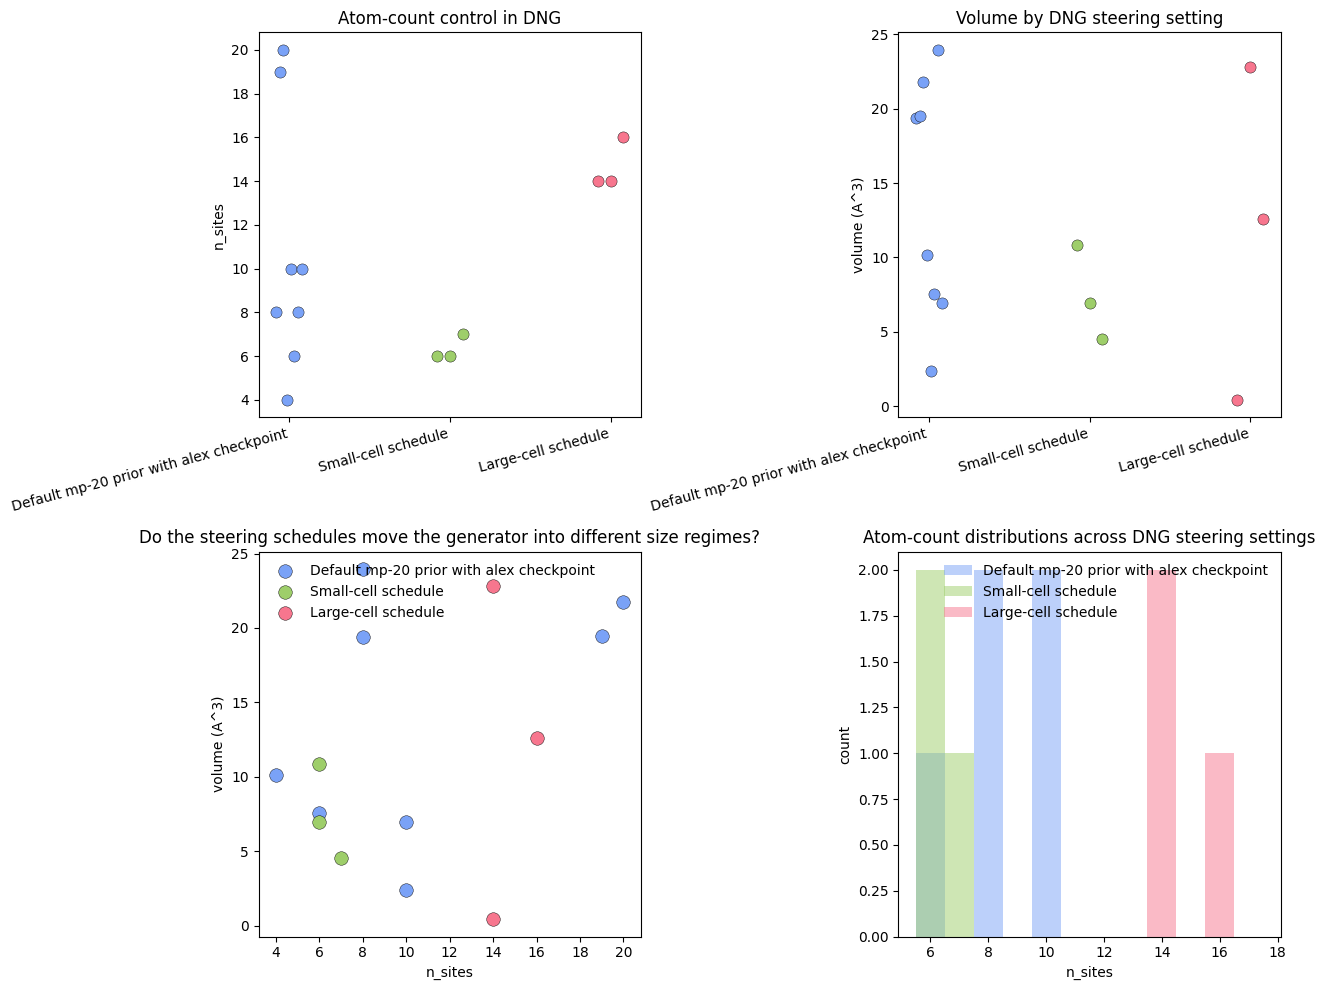

display_name,formula,n_sites,volume
Default mp-20 prior with alex checkpoint,H4,4,10.137
Small-cell schedule,H6,6,6.944
Default mp-20 prior with alex checkpoint,H5Be,6,7.556
Small-cell schedule,H4Be2,6,10.832


display_name,formula,n_sites,volume
Default mp-20 prior with alex checkpoint,H16O4,20,21.760
Default mp-20 prior with alex checkpoint,H18Be,19,19.487
Large-cell schedule,H10BeNNi4,16,12.597
Large-cell schedule,H13Be,14,22.788


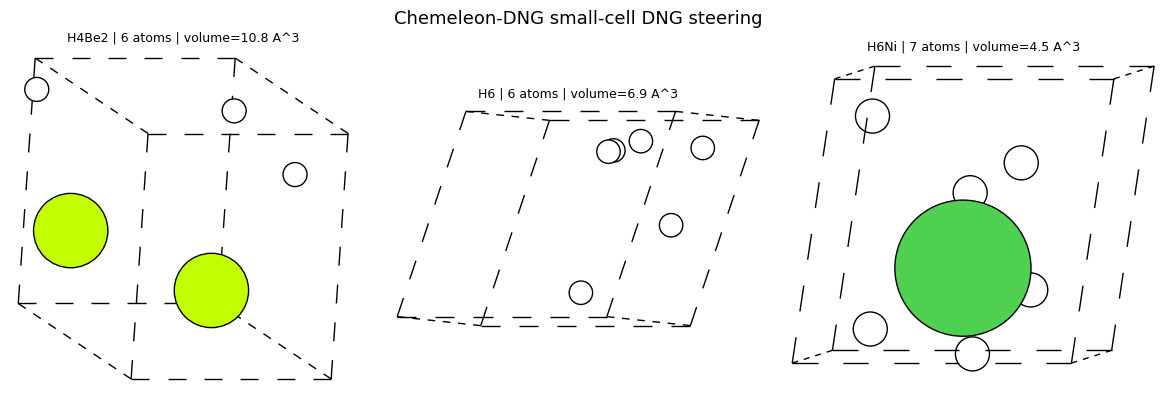

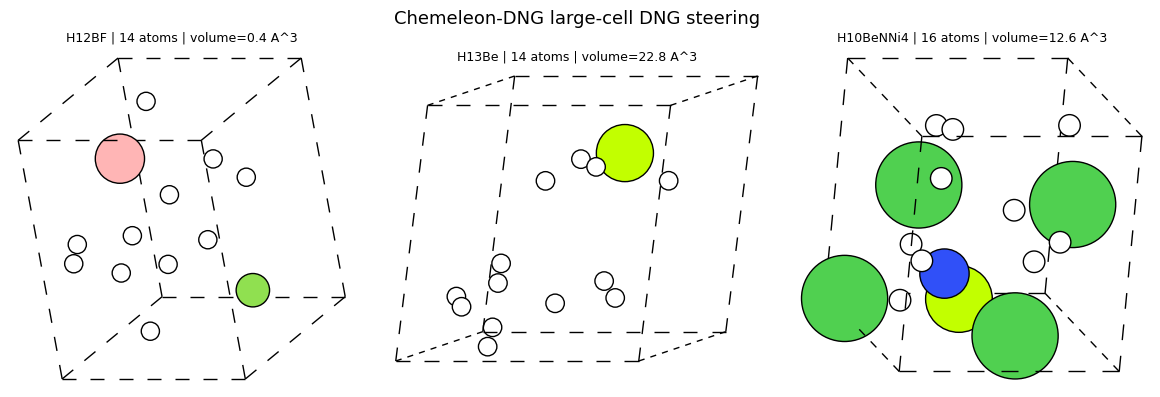

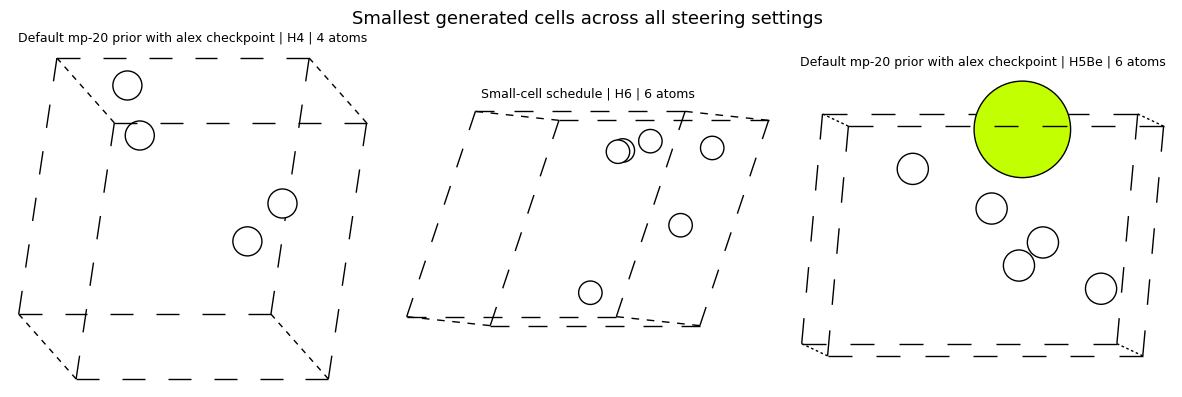

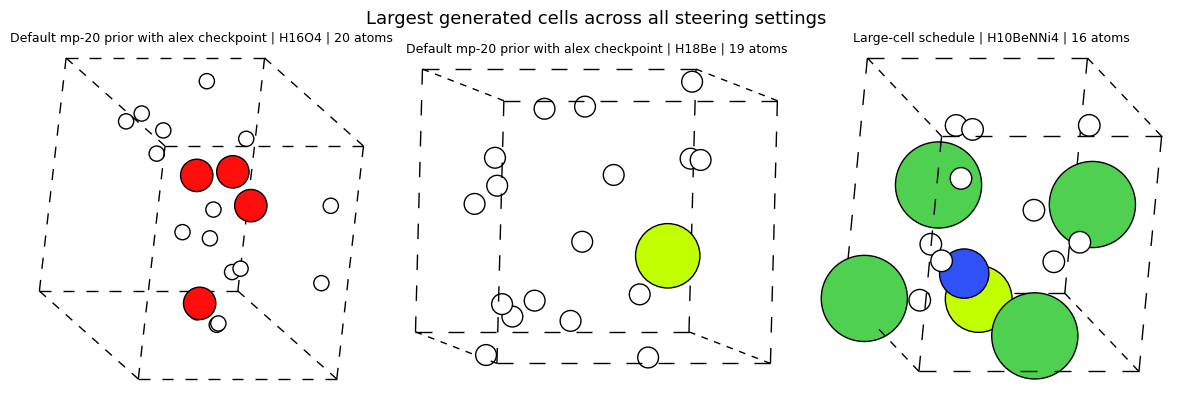

setting,mean_n_sites,delta_mean_n_sites,mean_volume,delta_mean_volume,unique_formulas
Default mp-20 prior with alex checkpoint,10.625,0.000,13.950,0.000,8
Small-cell schedule,6.333,-4.292,7.428,-6.521,3
Large-cell schedule,14.667,4.042,11.940,-2.009,3


In [3]:
from ase.io import read

CHEMELEON_DNG_CHECKPOINT_DATASET = globals().get('CHEMELEON_DNG_CHECKPOINT_DATASET', 'alex_mp_20')
CHEMELEON_DNG_PRIOR_NAME = globals().get('CHEMELEON_DNG_PRIOR_NAME', 'mp-20')
CHEMELEON_DNG_ALEX_MP20_MODEL_PATH = globals().get('CHEMELEON_DNG_ALEX_MP20_MODEL_PATH', 'ckpts/chemeleon_dng_alex_mp_20_v0.0.2.ckpt')

CHEMELEON_DNG_SMALL_SCHEDULE_TEXT = globals().get('CHEMELEON_DNG_SMALL_SCHEDULE_TEXT', '6, 6, 7')  # @param {type:"string"}
CHEMELEON_DNG_LARGE_SCHEDULE_TEXT = globals().get('CHEMELEON_DNG_LARGE_SCHEDULE_TEXT', '14, 14, 16')  # @param {type:"string"}
CHEMELEON_DNG_STEERING_REUSE_EXISTING = globals().get('CHEMELEON_DNG_STEERING_REUSE_EXISTING', True)  # @param {type:"boolean"}


def _parse_chemeleon_schedule(text: str, label: str):
    items = [item.strip() for item in str(text).split(',') if item.strip()]
    if not items:
        raise ValueError(f'{label} schedule cannot be empty.')
    schedule = [int(item) for item in items]
    if any(value <= 0 for value in schedule):
        raise ValueError(f'{label} schedule must contain positive integers only.')
    return schedule


def _chemeleon_steering_summary() -> str:
    lines = [
        'Chemeleon-DNG steering settings:',
        f'  small-cell schedule: {CHEMELEON_DNG_SMALL_SCHEDULE}',
        f'  large-cell schedule: {CHEMELEON_DNG_LARGE_SCHEDULE}',
        f'  baseline prior: {CHEMELEON_DNG_PRIOR_NAME}',
        f'  checkpoint dataset: {CHEMELEON_DNG_CHECKPOINT_DATASET}',
        f'  checkpoint: {CHEMELEON_DNG_ALEX_MP20_MODEL_PATH}',
        f'  reuse_existing: {CHEMELEON_DNG_STEERING_REUSE_EXISTING}',
    ]
    if not IN_COLAB and widgets is not None:
        lines.append('Adjust the schedules, then rerun this cell to regenerate the steering comparison.')
    return '\n'.join(lines)


def _apply_chemeleon_steering_controls(small_text, large_text, reuse_existing, announce: bool = True):
    global CHEMELEON_DNG_SMALL_SCHEDULE_TEXT, CHEMELEON_DNG_LARGE_SCHEDULE_TEXT
    global CHEMELEON_DNG_SMALL_SCHEDULE, CHEMELEON_DNG_LARGE_SCHEDULE, CHEMELEON_DNG_STEERING_REUSE_EXISTING
    CHEMELEON_DNG_SMALL_SCHEDULE_TEXT = str(small_text)
    CHEMELEON_DNG_LARGE_SCHEDULE_TEXT = str(large_text)
    CHEMELEON_DNG_SMALL_SCHEDULE = _parse_chemeleon_schedule(CHEMELEON_DNG_SMALL_SCHEDULE_TEXT, 'small-cell')
    CHEMELEON_DNG_LARGE_SCHEDULE = _parse_chemeleon_schedule(CHEMELEON_DNG_LARGE_SCHEDULE_TEXT, 'large-cell')
    CHEMELEON_DNG_STEERING_REUSE_EXISTING = bool(reuse_existing)
    summary = _chemeleon_steering_summary()
    if announce:
        print(summary)
    return summary


if IN_COLAB or widgets is None:
    print(_apply_chemeleon_steering_controls(CHEMELEON_DNG_SMALL_SCHEDULE_TEXT, CHEMELEON_DNG_LARGE_SCHEDULE_TEXT, CHEMELEON_DNG_STEERING_REUSE_EXISTING, announce=False))
    if not IN_COLAB and widgets is None:
        print('Install `ipywidgets` to get Jupyter controls for this cell.')
else:
    small_schedule_widget = widgets.Text(value=str(CHEMELEON_DNG_SMALL_SCHEDULE_TEXT), description='Small:', style={'description_width': '70px'}, layout=widgets.Layout(width='320px'))
    large_schedule_widget = widgets.Text(value=str(CHEMELEON_DNG_LARGE_SCHEDULE_TEXT), description='Large:', style={'description_width': '70px'}, layout=widgets.Layout(width='320px'))
    steering_reuse_widget = widgets.Checkbox(value=bool(CHEMELEON_DNG_STEERING_REUSE_EXISTING), description='Reuse existing CIFs')
    steering_help = widgets.HTML('<small>Use comma-separated atom counts. The schedule length sets how many samples are generated in each steering run.</small>')
    steering_status = widgets.HTML()
    display(widgets.VBox([widgets.HBox([small_schedule_widget, large_schedule_widget]), steering_reuse_widget, steering_help, steering_status]))

    def _refresh_chemeleon_steering(small_text, large_text, reuse_existing):
        steering_status.value = format_widget_pre(
            _apply_chemeleon_steering_controls(small_text, large_text, reuse_existing, announce=False)
        )

    bind_widget_state(
        {'small_text': small_schedule_widget, 'large_text': large_schedule_widget, 'reuse_existing': steering_reuse_widget},
        _refresh_chemeleon_steering,
    )

_apply_chemeleon_steering_controls(CHEMELEON_DNG_SMALL_SCHEDULE_TEXT, CHEMELEON_DNG_LARGE_SCHEDULE_TEXT, CHEMELEON_DNG_STEERING_REUSE_EXISTING, announce=False)
if 'dng_atoms_list' not in globals() or not dng_atoms_list:
    baseline_num_samples = int(globals().get('CHEMELEON_DNG_QUICKSTART_NUM_SAMPLES', 8))
    baseline_batch_size = int(globals().get('CHEMELEON_DNG_QUICKSTART_BATCH_SIZE', baseline_num_samples))
    baseline_reuse_existing = bool(globals().get('CHEMELEON_DNG_QUICKSTART_REUSE_EXISTING', True))
    baseline_output_dir = CHEMELEON_DNG_OUT / 'dng_quickstart'
    baseline_cif_paths = sample_chemeleon_dng(
        task='dng',
        num_samples=baseline_num_samples,
        batch_size=baseline_batch_size,
        output_dir=baseline_output_dir,
        device=CHEMELEON_DNG_DEVICE,
        num_atom_distribution=CHEMELEON_DNG_PRIOR_NAME,
        model_path=CHEMELEON_DNG_ALEX_MP20_MODEL_PATH,
        reuse_existing=baseline_reuse_existing,
    )
    dng_atoms_list = [read(path) for path in baseline_cif_paths]
    print(f'Loaded {len(dng_atoms_list)} baseline DNG structures for comparison')

dng_small_output_dir = CHEMELEON_DNG_OUT / 'dng_small_cells'
dng_large_output_dir = CHEMELEON_DNG_OUT / 'dng_large_cells'
dng_small_cif_paths = sample_chemeleon_dng(task='dng', num_samples=len(CHEMELEON_DNG_SMALL_SCHEDULE), batch_size=len(CHEMELEON_DNG_SMALL_SCHEDULE), output_dir=dng_small_output_dir, device=CHEMELEON_DNG_DEVICE, num_atom_distribution=CHEMELEON_DNG_SMALL_SCHEDULE, model_path=CHEMELEON_DNG_ALEX_MP20_MODEL_PATH, reuse_existing=CHEMELEON_DNG_STEERING_REUSE_EXISTING)
dng_large_cif_paths = sample_chemeleon_dng(task='dng', num_samples=len(CHEMELEON_DNG_LARGE_SCHEDULE), batch_size=len(CHEMELEON_DNG_LARGE_SCHEDULE), output_dir=dng_large_output_dir, device=CHEMELEON_DNG_DEVICE, num_atom_distribution=CHEMELEON_DNG_LARGE_SCHEDULE, model_path=CHEMELEON_DNG_ALEX_MP20_MODEL_PATH, reuse_existing=CHEMELEON_DNG_STEERING_REUSE_EXISTING)
dng_run_atoms = {'baseline_prior': dng_atoms_list, 'small_cells': [read(path) for path in dng_small_cif_paths], 'large_cells': [read(path) for path in dng_large_cif_paths]}
dng_run_titles = {'baseline_prior': 'Default mp-20 prior with alex checkpoint', 'small_cells': 'Small-cell schedule', 'large_cells': 'Large-cell schedule'}
dng_colors = {'baseline_prior': '#7aa2f7', 'small_cells': '#9ece6a', 'large_cells': '#f7768e'}
dng_analysis = analyze_dng_runs(dng_run_atoms, dng_run_titles, CHEMELEON_DNG_OUT, colors=dng_colors)
dng_rows = dng_analysis['rows']
dng_shift_rows = dng_analysis['shift_rows']
dng_sorted_by_n_sites = dng_analysis['sorted_by_n_sites']
render_rank_table(
    'How the DNG steering schedules shift the generated distribution',
    dng_shift_rows,
    ['setting', 'mean_n_sites', 'delta_mean_n_sites', 'mean_volume', 'delta_mean_volume', 'unique_formulas'],
)


## Optional: SMACT formula screening before CSP

The upstream `tutorial.ipynb` does not jump straight from open-ended generation to CSP. It first screens a chemical system for simple charge-balanced, chemically plausible formulas. That is useful here too, because it turns “which formulas should I try?” into a small, explicit pre-processing step.

This is especially helpful if you want to move from DNG-style exploration to a more targeted CSP study.


In [4]:
SMACT_ELEMENTS_TEXT = globals().get('SMACT_ELEMENTS_TEXT', 'Li, Mn, O')  # @param {type:"string"}
SMACT_MAX_STOICHIOMETRY = int(globals().get('SMACT_MAX_STOICHIOMETRY', 4))  # @param {type:"integer"}
SMACT_COMMONALITY = globals().get('SMACT_COMMONALITY', 'medium')  # @param ["low", "medium", "high", "main"]

smact_elements = [item.strip() for item in str(SMACT_ELEMENTS_TEXT).split(',') if item.strip()]
smact_formula_rows = get_valid_compositions(
    smact_elements,
    max_stoichiometry=SMACT_MAX_STOICHIOMETRY,
    commonality=SMACT_COMMONALITY,
)
print(f"Suggested CSP formulas for {smact_elements}:")
for row in smact_formula_rows[:10]:
    print('-', row['formula'])
if smact_formula_rows:
    render_rank_table(
        'SMACT-screened formulas you could paste into the CSP cell below',
        smact_formula_rows[:10],
        ['formula', 'num_elements', 'num_atoms_in_reduced_formula'],
    )
    print('Try pasting one or two of these formulas into CHEMELEON_CSP_TARGETS_TEXT in the next section.')
else:
    print('No charge-balanced formulas were found for this element set and commonality threshold.')


Suggested CSP formulas for ['Li', 'Mn', 'O']:
- LiMnO2
- Li2MnO2
- Li2MnO3
- Li2Mn2O3
- Li3MnO3
- Li4MnO3
- Li2Mn3O4
- Li4MnO4


formula,num_elements,num_atoms_in_reduced_formula
LiMnO2,3,4
Li2MnO2,3,5
Li2MnO3,3,6
Li2Mn2O3,3,7
Li3MnO3,3,7
Li4MnO3,3,8
Li2Mn3O4,3,9
Li4MnO4,3,9


Try pasting one or two of these formulas into CHEMELEON_CSP_TARGETS_TEXT in the next section.


## 5) CSP quickstart: formula-conditioned generation

Now we switch from open-ended DNG to the explicitly conditioned Chemeleon-DNG task.

Here the condition is a target **formula**, so the chemistry is fixed and the model only has to infer plausible crystal structures for that composition.

### What to notice

- This is the cleanest Chemeleon-DNG example of conditional generation.
- Unlike MatterGen's scalar target, a formula condition is easy to verify directly from the output stoichiometry.
- The optional SMACT section above is one way to choose formulas more deliberately instead of guessing them by hand.
- The natural application is formula screening: pick one or two candidate chemistries, generate several structures for each, then rank them with cheap diagnostics before doing more expensive physics.

> **Quick check:** why is CSP a stronger demonstration of conditioning than a single DNG run?
>
><details><summary>Answer</summary>
>
>Because the condition is explicit and verifiable. You can directly check whether the generated structures respect the requested composition and whether different formulas occupy different structural regimes.
>
></details>


Reusing 2 existing CIF files from /home/uccabaa/repositories/tutorials/notebooks/05-generative/results_chemeleon_dng/csp_nacl
NaCl: 2 structures


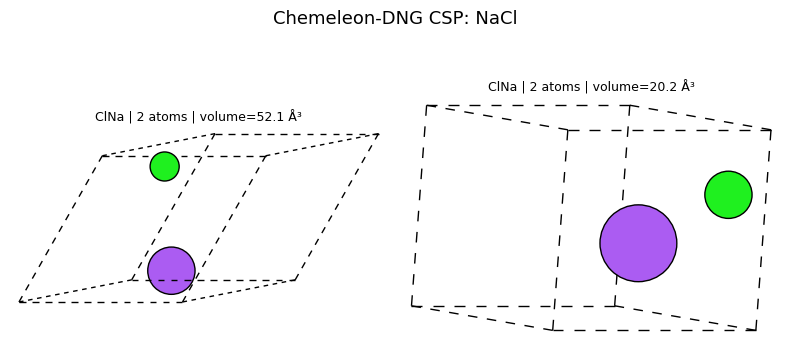

Reusing 2 existing CIF files from /home/uccabaa/repositories/tutorials/notebooks/05-generative/results_chemeleon_dng/csp_limno2
LiMnO2: 2 structures


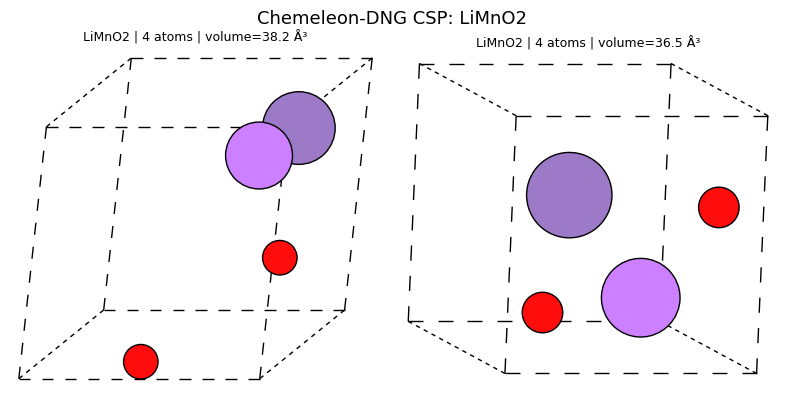

In [5]:
from ase.io import read

CHEMELEON_CSP_TARGETS_TEXT = globals().get('CHEMELEON_CSP_TARGETS_TEXT', 'NaCl, LiMnO2')  # @param {type:"string"}
CSP_SAMPLES_PER_FORMULA = int(globals().get('CSP_SAMPLES_PER_FORMULA', 2))  # @param {type:"integer"}
CHEMELEON_CSP_BATCH_SIZE = int(globals().get('CHEMELEON_CSP_BATCH_SIZE', 2))  # @param {type:"integer"}
CHEMELEON_CSP_REUSE_EXISTING = globals().get('CHEMELEON_CSP_REUSE_EXISTING', True)  # @param {type:"boolean"}


def _parse_csp_targets(text: str):
    targets = [item.strip() for item in str(text).split(',') if item.strip()]
    if not targets:
        raise ValueError('Provide at least one CSP target formula.')
    return targets


def _chemeleon_csp_summary() -> str:
    lines = [
        'Chemeleon-DNG CSP settings:',
        f'  formulas: {csp_targets}',
        f'  samples_per_formula: {CSP_SAMPLES_PER_FORMULA}',
        f'  batch_size: {CHEMELEON_CSP_BATCH_SIZE}',
        f'  checkpoint: {CHEMELEON_CSP_ALEX_MP20_MODEL_PATH}',
        f'  reuse_existing: {CHEMELEON_CSP_REUSE_EXISTING}',
    ]
    if not IN_COLAB and widgets is not None:
        lines.append('Adjust the widgets, then rerun this cell to launch a new CSP comparison.')
    return '\n'.join(lines)


def _apply_chemeleon_csp_controls(targets_text, samples_per_formula, batch_size, reuse_existing, announce: bool = True):
    global CHEMELEON_CSP_TARGETS_TEXT, csp_targets, CSP_SAMPLES_PER_FORMULA
    global CHEMELEON_CSP_BATCH_SIZE, CHEMELEON_CSP_REUSE_EXISTING
    CHEMELEON_CSP_TARGETS_TEXT = str(targets_text)
    csp_targets = _parse_csp_targets(CHEMELEON_CSP_TARGETS_TEXT)
    CSP_SAMPLES_PER_FORMULA = int(samples_per_formula)
    CHEMELEON_CSP_BATCH_SIZE = int(batch_size)
    CHEMELEON_CSP_REUSE_EXISTING = bool(reuse_existing)
    summary = _chemeleon_csp_summary()
    if announce:
        print(summary)
    return summary


if IN_COLAB or widgets is None:
    print(_apply_chemeleon_csp_controls(CHEMELEON_CSP_TARGETS_TEXT, CSP_SAMPLES_PER_FORMULA, CHEMELEON_CSP_BATCH_SIZE, CHEMELEON_CSP_REUSE_EXISTING, announce=False))
    if not IN_COLAB and widgets is None:
        print('Install `ipywidgets` to get Jupyter controls for this cell.')
else:
    csp_targets_widget = widgets.Text(value=str(CHEMELEON_CSP_TARGETS_TEXT), description='Formulas:', style={'description_width': '70px'}, layout=widgets.Layout(width='360px'))
    csp_samples_widget = widgets.BoundedIntText(value=CSP_SAMPLES_PER_FORMULA, min=1, max=8, description='Samples:', style={'description_width': '70px'}, layout=widgets.Layout(width='200px'))
    csp_batch_widget = widgets.BoundedIntText(value=CHEMELEON_CSP_BATCH_SIZE, min=1, max=8, description='Batch size:', style={'description_width': '70px'}, layout=widgets.Layout(width='200px'))
    csp_reuse_widget = widgets.Checkbox(value=bool(CHEMELEON_CSP_REUSE_EXISTING), description='Reuse existing CIFs')
    csp_help = widgets.HTML('<small>Use comma-separated formulas. Update the controls below and rerun this cell to regenerate the CSP galleries.</small>')
    csp_status = widgets.HTML()
    display(widgets.VBox([widgets.HBox([csp_targets_widget, csp_samples_widget, csp_batch_widget]), csp_reuse_widget, csp_help, csp_status]))

    def _refresh_chemeleon_csp(targets_text, samples_per_formula, batch_size, reuse_existing):
        csp_status.value = format_widget_pre(
            _apply_chemeleon_csp_controls(targets_text, samples_per_formula, batch_size, reuse_existing, announce=False)
        )

    bind_widget_state(
        {'targets_text': csp_targets_widget, 'samples_per_formula': csp_samples_widget, 'batch_size': csp_batch_widget, 'reuse_existing': csp_reuse_widget},
        _refresh_chemeleon_csp,
    )

_apply_chemeleon_csp_controls(CHEMELEON_CSP_TARGETS_TEXT, CSP_SAMPLES_PER_FORMULA, CHEMELEON_CSP_BATCH_SIZE, CHEMELEON_CSP_REUSE_EXISTING, announce=False)
csp_samples = {}
for formula in csp_targets:
    out_dir = CHEMELEON_DNG_OUT / f'csp_{formula.lower()}'
    cif_paths = sample_chemeleon_dng(task='csp', formulas=[formula], num_samples=CSP_SAMPLES_PER_FORMULA, batch_size=CHEMELEON_CSP_BATCH_SIZE, output_dir=out_dir, device=CHEMELEON_DNG_DEVICE, model_path=CHEMELEON_CSP_ALEX_MP20_MODEL_PATH, reuse_existing=CHEMELEON_CSP_REUSE_EXISTING)
    atoms_list = [read(path) for path in cif_paths]
    csp_samples[formula] = atoms_list
    print(f'{formula}: {len(atoms_list)} structures')
    show_atoms_gallery(atoms_list, f'Chemeleon-DNG CSP: {formula}', CHEMELEON_DNG_OUT / f'csp_{formula.lower()}_gallery.png', subtitles=[f"{atoms.get_chemical_formula()} | {len(atoms)} atoms | volume={atoms.get_volume():.1f} Å³" for atoms in atoms_list])


## 6) CSP conditioning shifts, galleries, and screening

Once we have multiple CSP samples per formula, the notebook can do more than show one gallery. We can compare how the target chemistry changes formula-match fraction, volume, and atom-count distributions, then rank the outputs as a tiny formula-conditioned discovery workflow.

### What to notice

- Formula conditioning should separate the outputs into different structural regions.
- The same cheap screening ideas from the MatterGen section still apply here, but now formula-match fraction is the most direct check of conditioning success.
- Ranking the matching and off-target candidates separately is more informative than collapsing everything onto one generic structural proxy.
- These plots tell you whether the chemistry was respected; they do not replace relaxation or stability analysis.

> **Quick check:** what is the conceptual difference between *conditioning* and *screening* in this CSP workflow?
>
><details><summary>Answer</summary>
>
>Conditioning tells the generator what chemistry to realize. Screening happens afterward, when you compute simple statistics such as formula-match fraction, atom count, or volume to decide which generated candidates deserve closer study.
>
></details>


Loaded 4 CSP structures across 2 formulas
- NaCl: mean volume=36.15, mean n_sites=2.00, formula-match fraction=1.00
- LiMnO2: mean volume=37.37, mean n_sites=4.00, formula-match fraction=1.00


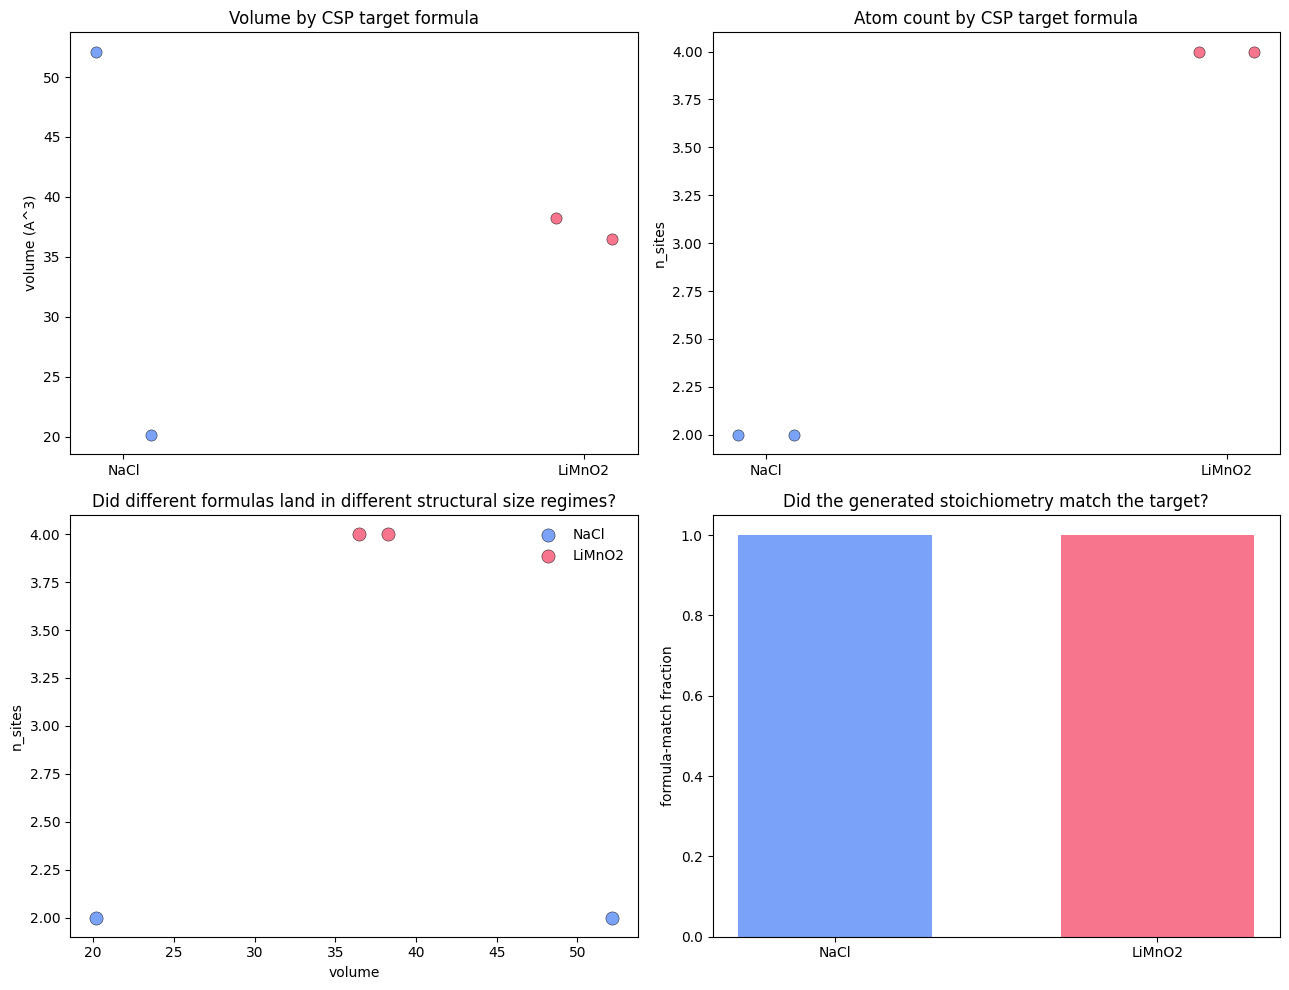

formula_target,generated_formula,n_sites,volume
LiMnO2,LiMnO2,4,36.492
LiMnO2,LiMnO2,4,38.247
NaCl,ClNa,2,20.164
NaCl,ClNa,2,52.129


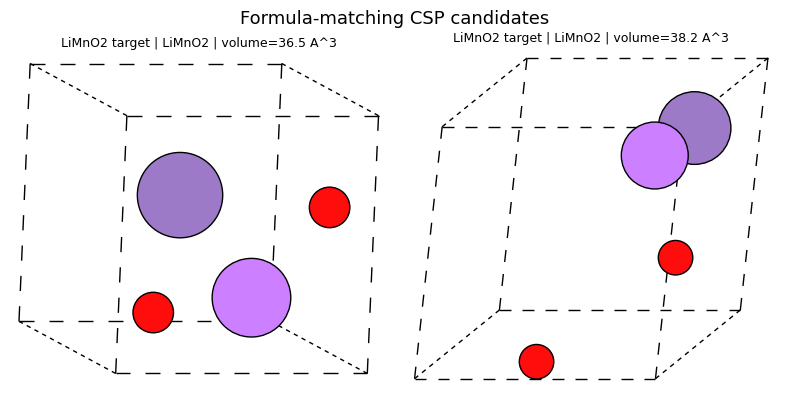

formula_target,formula_match_fraction,mean_n_sites,mean_volume
NaCl,1.000,2.000,36.147
LiMnO2,1.000,4.000,37.369


In [6]:
csp_analysis = analyze_csp_samples(csp_samples, csp_targets, CHEMELEON_DNG_OUT)
csp_rows = csp_analysis["rows"]
csp_summary_rows = csp_analysis["summary_rows"]
csp_matching_rows = csp_analysis["matching_rows"]
csp_mismatched_rows = csp_analysis["mismatched_rows"]

render_rank_table(
    'How strongly did the CSP formulas separate the generated samples?',
    csp_summary_rows,
    ['formula_target', 'formula_match_fraction', 'mean_n_sites', 'mean_volume'],
)


## Optional: relaxation and stability triage

Like in `mattergen-crystals.ipynb`, we don't have to stop at generation. Take a small CSP shortlist, relax it with MACE + TorchSim, then compare those relaxed candidates against a Materials Project phase diagram.

Why does this fit Chemeleon especially well?

- CSP fixes the composition, so all shortlisted candidates belong to one clean chemical system.
- That makes phase-diagram analysis much easier than for MatterGen.


In [7]:
CHEMELEON_DISCOVERY_INSTALL = globals().get('CHEMELEON_DISCOVERY_INSTALL', True)  # @param {type:"boolean"}

if CHEMELEON_DISCOVERY_INSTALL:
    !python -m pip install smact==3.2.0 mace-torch==0.3.14 torch-sim-atomistic==0.3.0 mp_api==0.45.13 pymatgen
else:
    print('Set CHEMELEON_DISCOVERY_INSTALL=True and rerun this cell the first time you want SMACT, MACE/TorchSim relaxation, or MP phase-diagram analysis in this notebook.')


Defaulting to user installation because normal site-packages is not writeable
  Using cached e3nn-0.4.4-py3-none-any.whl.metadata (5.1 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached matscipy-1.2.0-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (37 kB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached lmdb-2.2.0-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (1.2 kB)
  Using cached opt_einsum_fx-0.1.4-py3-none-any.whl.metadata (3.3 kB)
  Using cached ase-3.28.0-py3-none-any.whl.metadata (4.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 16.8 MB/s  0:00:00
Using cached e3nn-0.4.4-py3-none-any.whl (387 kB)
Using cached opt_einsum_fx-0.1.4-py3-none-any.whl (13 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 22.9 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━

In [8]:
CHEMELEON_RELAX_FORMULA = globals().get('CHEMELEON_RELAX_FORMULA', csp_targets[0] if csp_targets else 'NaCl')  # @param {type:"string"}
CHEMELEON_RELAX_NUM_CANDIDATES = int(globals().get('CHEMELEON_RELAX_NUM_CANDIDATES', 2))  # @param {type:"integer"}
CHEMELEON_RELAX_DEVICE = globals().get('CHEMELEON_RELAX_DEVICE', 'cpu')  # @param ["cpu", "cuda"]
CHEMELEON_RELAX_MODEL_SIZE = globals().get('CHEMELEON_RELAX_MODEL_SIZE', 'small')  # @param ["small", "medium"]
CHEMELEON_RUN_RELAXATION = globals().get('CHEMELEON_RUN_RELAXATION', True)  # @param {type:"boolean"}

preferred_rows = [row for row in csp_matching_rows if row['formula_target'] == CHEMELEON_RELAX_FORMULA]
if not preferred_rows:
    preferred_rows = [row for row in csp_rows if row['formula_target'] == CHEMELEON_RELAX_FORMULA]
if not preferred_rows:
    raise ValueError(f'No CSP candidates found for {CHEMELEON_RELAX_FORMULA}.')

selected_relax_rows = preferred_rows[:CHEMELEON_RELAX_NUM_CANDIDATES]
selected_relax_atoms = [row['atoms'] for row in selected_relax_rows]
selected_relax_labels = [f"{row['formula_target']} sample {row['sample_id']}" for row in selected_relax_rows]

if not CHEMELEON_RUN_RELAXATION:
    print('Set CHEMELEON_RUN_RELAXATION=True and rerun this cell to relax a small CSP shortlist with MACE + TorchSim.')
else:
    try:
        chemeleon_relaxation = relax_atoms_with_mace(
            selected_relax_atoms,
            device=CHEMELEON_RELAX_DEVICE,
            model_size=CHEMELEON_RELAX_MODEL_SIZE,
        )
    except ImportError as exc:
        print('Optional relaxation dependencies are missing in this Python environment.')
        print('Set CHEMELEON_DISCOVERY_INSTALL=True and rerun the install cell first.')
        print(f'Details: {exc}')
    else:
        chemeleon_relaxed_atoms = chemeleon_relaxation['relaxed_atoms']
        chemeleon_relaxation_rows = build_relaxation_rows(
            selected_relax_atoms,
            chemeleon_relaxed_atoms,
            chemeleon_relaxation['energies'],
            labels=selected_relax_labels,
        )
        render_rank_table(
            'Shortlist after MACE/TorchSim relaxation',
            chemeleon_relaxation_rows,
            ['label', 'formula_before', 'formula_after', 'n_sites', 'energy_eV', 'volume_before', 'volume_after', 'delta_volume'],
        )
        show_before_after_relaxation(
            selected_relax_atoms,
            chemeleon_relaxed_atoms,
            selected_relax_labels,
            f'Chemeleon CSP relaxation shortlist for {CHEMELEON_RELAX_FORMULA}',
            save_path=CHEMELEON_DNG_OUT / f"csp_relax_{CHEMELEON_RELAX_FORMULA.lower()}.png",
        )


/home/uccabaa/.local/lib/python3.12/site-packages/e3nn/o3/_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.dirname(__file__), 'constants.pt'))


cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.
Optional relaxation dependencies are missing in this Python environment.
Set CHEMELEON_DISCOVERY_INSTALL=True and rerun the install cell first.
Details: No module named '_bz2'


In [9]:
try:
    from pymatgen.core import Composition
except Exception as exc:
    Composition = None
    _composition_import_error = exc
else:
    _composition_import_error = None

CHEMELEON_MP_API_KEY = globals().get('CHEMELEON_MP_API_KEY', os.environ.get('MP_API_KEY', ''))  # @param {type:"string"}
CHEMELEON_RUN_STABILITY = globals().get('CHEMELEON_RUN_STABILITY', True)  # @param {type:"boolean"}
CHEMELEON_STABLE_CUTOFF = float(globals().get('CHEMELEON_STABLE_CUTOFF', 0.10))  # @param {type:"number"}

if not CHEMELEON_RUN_STABILITY:
    print('Set CHEMELEON_RUN_STABILITY=True and rerun this cell to compare the relaxed shortlist against the Materials Project phase diagram.')
elif 'chemeleon_relaxed_atoms' not in globals() or 'chemeleon_relaxation' not in globals():
    print('Run the relaxation cell above first.')
elif Composition is None:
    print('Phase-diagram analysis is optional and requires a working pymatgen installation.')
    print('In this Python build that stack is currently unavailable.')
    print(f'Details: {_composition_import_error}')
elif not CHEMELEON_MP_API_KEY:
    print('Provide CHEMELEON_MP_API_KEY or set MP_API_KEY in the environment before rerunning this cell.')
else:
    try:
        chemsys = [element.symbol for element in Composition(CHEMELEON_RELAX_FORMULA).elements]
        mp_entries = fetch_mp_entries_for_chemsys(chemsys, CHEMELEON_MP_API_KEY)
        generated_entries = build_generated_pd_entries(chemeleon_relaxed_atoms, chemeleon_relaxation['energies'])
        stability = summarize_generated_stability(
            mp_entries,
            generated_entries,
            labels=selected_relax_labels,
            stable_cutoff=CHEMELEON_STABLE_CUTOFF,
        )
    except ImportError as exc:
        print('Phase-diagram analysis is optional and requires a working pymatgen installation.')
        print(f'Details: {exc}')
    else:
        render_rank_table(
            'Energy-above-hull triage for the relaxed CSP shortlist',
            stability['rows'],
            ['label', 'formula', 'energy_above_hull_eV_per_atom', 'is_stable_or_close'],
        )
        phase_plot = plot_phase_diagram_with_generated(mp_entries, generated_entries)
        try:
            phase_plot.show()
        except Exception:
            display(phase_plot)


Run the relaxation cell above first.


## 7) Exercises

1. **DNG vs CSP:** In your own words, what is the difference between DNG and CSP?

<details><summary>Answer</summary>

DNG generates structures from scratch, while CSP generates structures conditioned on a target formula.

</details>

2. **Band gap vs formula conditioning:** How does MatterGen's low-vs-high band-gap sweep differ from Chemeleon-DNG's CSP sweep?

<details><summary>Answer</summary>

MatterGen changes a scalar target while leaving the chemistry open, whereas CSP fixes the chemistry directly and asks the model to generate plausible structures for that formula.

</details>

3. **Direct vs indirect evidence:** Which CSP plots tell you about conditioning success most directly: formula-match fraction, volume, or `n_sites`?

<details><summary>Answer</summary>

Formula-match fraction is the most direct evidence because it tests whether the generated stoichiometry actually matches the requested formula. Volume and `n_sites` are still useful, but they are indirect structural consequences rather than the condition itself.

</details>

4. **Pick the right tool:** When would you choose Chemeleon-DNG over MatterGen?

<details><summary>Answer</summary>

Chemeleon-DNG is a good choice when you want a compact DNG/CSP workflow, especially if your main question is composition-conditioned structure generation.

</details>

5. **Discovery funnel:** Suppose one CSP formula looks promising. What is the next workflow after generation in this notebook?

<details><summary>Answer</summary>

Shortlist the matching candidates, relax them, and then compare the relaxed structures against a phase diagram or another stability metric before committing to more expensive calculations.

</details>

6. **Why phase diagrams here?** Why is the optional phase-diagram analysis cleaner in the Chemeleon CSP notebook than in the MatterGen notebook?

<details><summary>Answer</summary>

Because CSP fixes the composition, so all shortlisted structures belong to one well-defined chemical system. That makes it natural to compare them against a single Materials Project phase diagram.

</details>


## 9) Troubleshooting

- If `chemeleon_dng_repo/` exists but has no `pyproject.toml`, rerun the setup cell. The setup checks for incomplete clones, moves them aside, and reclones the repo cleanly.
- The Python environment lives in `tempfile.gettempdir()/chemeleon-dng-venv` rather than inside the repo. That avoids incomplete `torch` and `numpy` installs on mounted filesystems such as WSL/Colab paths.
- The notebook anchors itself to the repo root, so outputs land inside `notebooks/05-generative/` for this tutorial repo rather than the parent directory.
- The first DNG or CSP run downloads about $523\,\mathrm{MB}$ of checkpoints into `chemeleon_dng_repo/ckpts/`. If that download is interrupted, rerun the first sampling cell.
- The Chemeleon subprocess forces `MPLBACKEND='Agg'` and uses a writable temporary Matplotlib cache, so it does not inherit Jupyter's inline backend and fail during import.
- The sampling helper reuses existing CIFs by default when the output directory already contains the expected number of structures. If you want a fully fresh run, delete the relevant output directory first.
- `CHEMELEON_DNG_DEMO_TIMESTEPS` controls the notebook-speed reverse process. Increase it if you want higher-fidelity samples and can tolerate longer runtimes.

## 10) Next steps

- In MatterGen, try a second conditioned checkpoint such as `chemical_system` or `space_group` and repeat the same sweep-plus-screening workflow.
- In Chemeleon-DNG, expand the CSP formula list and compare how the volume / atom-count clouds move as the chemistry changes.
- Turn on the optional SMACT, relaxation, and phase-diagram cells for one chemical system you actually care about.
- Increase the DNG atom-count schedules from the tiny tutorial values here to broader small-cell and large-cell sweeps once you move to GPU.
- Build one shared post-processing script that ingests MatterGen and Chemeleon outputs together, then ranks candidates by the same screening criteria.
